<a href="https://colab.research.google.com/github/nikhilfendre/CSL701-CS15-Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Nikhil Prasad Fendre Roll No: CS15

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias

### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [27]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Iris dataset
df = pd.read_csv("Iris.csv")

# Display first 5 rows
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Task 2: Explore the Dataset

In [28]:
# Explore the dataset

# Display number of rows and columns
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display dataset information
print("\nDataset Information:")
df.info()

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Display number of samples in each class
print("\nSpecies Count:")
print(df['Species'].value_counts())

Dataset Shape: (150, 6)

Column Names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Statistical Summary:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594     

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [29]:
# Remove Id column
df = df.drop('Id', axis=1)

# Select features and target
X = df.drop('Species', axis=1)
y = df['Species']

# Display features
print("Features:")
print(X.head())

# Display target
print("\nTarget:")
print(y.head())

Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [30]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardize the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Display shapes
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [31]:
# Import SVM
from sklearn.svm import SVC

# Create Linear SVM model
svm_model = SVC(kernel='linear', random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Display predicted values
print("Predicted values:")
print(y_pred_svm)

# Display actual values
print("\nActual values:")
print(y_test.values)

Predicted values:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']

Actual values:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 

# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [32]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

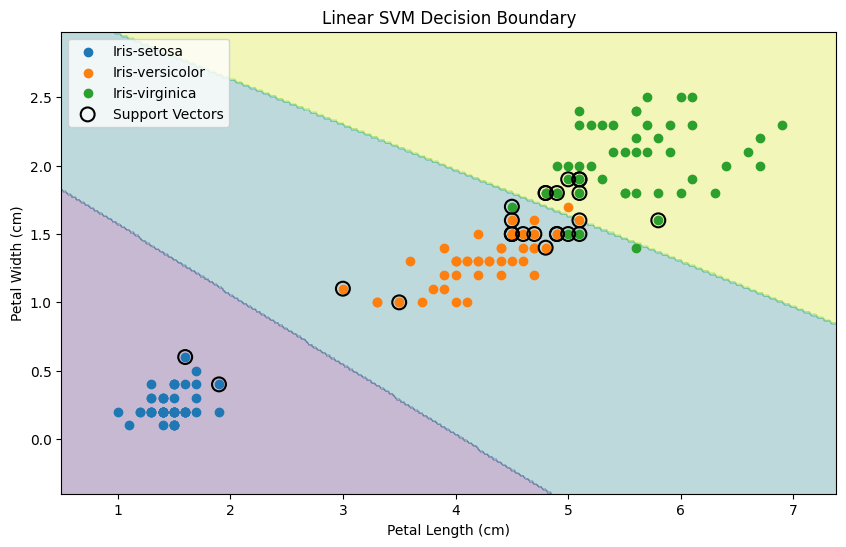

In [33]:
# Step 7 - SVM Decision Boundary Visualization

# Select Petal Length and Petal Width
X_2d = df[['PetalLengthCm', 'PetalWidthCm']]
y_2d = df['Species']

# Split the 2D dataset
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d,
    y_2d,
    test_size=0.2,
    random_state=42,
    stratify=y_2d
)

# Standardize the 2D features
scaler_2d = StandardScaler()

X2_train_scaled = scaler_2d.fit_transform(X2_train)
X2_test_scaled = scaler_2d.transform(X2_test)

# Train Linear SVM
svm_2d = SVC(kernel='linear', random_state=42)
svm_2d.fit(X2_train_scaled, y2_train)

# Create mesh grid
x_min = X_2d['PetalLengthCm'].min() - 0.5
x_max = X_2d['PetalLengthCm'].max() + 0.5

y_min = X_2d['PetalWidthCm'].min() - 0.5
y_max = X_2d['PetalWidthCm'].max() + 0.5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Convert mesh grid into DataFrame
grid = pd.DataFrame({
    'PetalLengthCm': xx.ravel(),
    'PetalWidthCm': yy.ravel()
})

# Scale mesh grid
grid_scaled = scaler_2d.transform(grid)

# Predict classes
Z = svm_2d.predict(grid_scaled)

# Convert text classes to numbers for plotting
class_mapping = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}

Z_numeric = np.array([class_mapping[value] for value in Z])
Z_numeric = Z_numeric.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10, 6))

plt.contourf(
    xx,
    yy,
    Z_numeric,
    alpha=0.3
)

# Plot data points
for class_name in [
    'Iris-setosa',
    'Iris-versicolor',
    'Iris-virginica'
]:
    mask = y_2d == class_name

    plt.scatter(
        X_2d.loc[mask, 'PetalLengthCm'],
        X_2d.loc[mask, 'PetalWidthCm'],
        label=class_name
    )

# Get support vectors
support_vectors = scaler_2d.inverse_transform(
    svm_2d.support_vectors_
)

# Plot support vectors
plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=100,
    facecolors='none',
    edgecolors='black',
    linewidths=1.5,
    label='Support Vectors'
)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Linear SVM Decision Boundary')
plt.legend()
plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

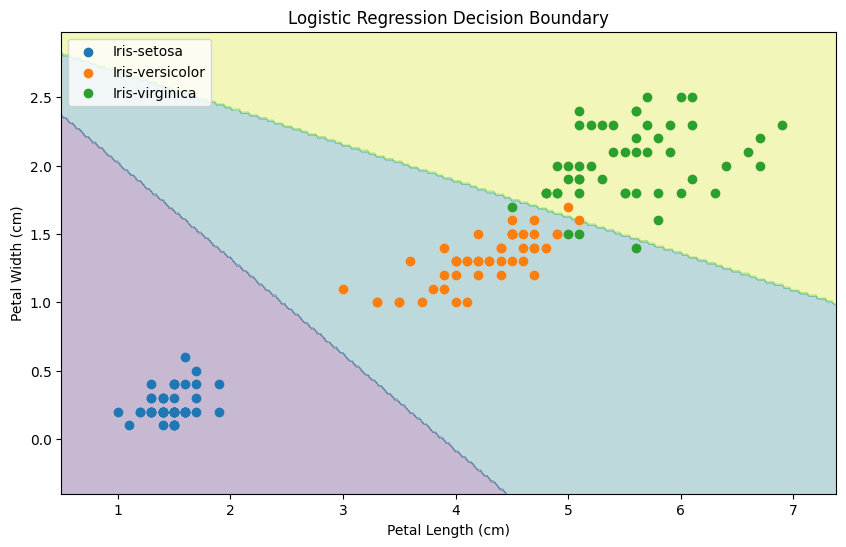

In [34]:
# Step 8 - Logistic Regression Decision Boundary

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(random_state=42)

# Train the model using the same 2D scaled training data
logistic_model.fit(X2_train_scaled, y2_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X2_test_scaled)

# Predict classes for the mesh grid
Z_logistic = logistic_model.predict(grid_scaled)

# Convert text classes to numbers for plotting
Z_logistic_numeric = np.array([
    class_mapping[value] for value in Z_logistic
])

Z_logistic_numeric = Z_logistic_numeric.reshape(xx.shape)

# Plot Logistic Regression decision boundary
plt.figure(figsize=(10, 6))

plt.contourf(
    xx,
    yy,
    Z_logistic_numeric,
    alpha=0.3
)

# Plot data points
for class_name in [
    'Iris-setosa',
    'Iris-versicolor',
    'Iris-virginica'
]:
    mask = y_2d == class_name

    plt.scatter(
        X_2d.loc[mask, 'PetalLengthCm'],
        X_2d.loc[mask, 'PetalWidthCm'],
        label=class_name
    )

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

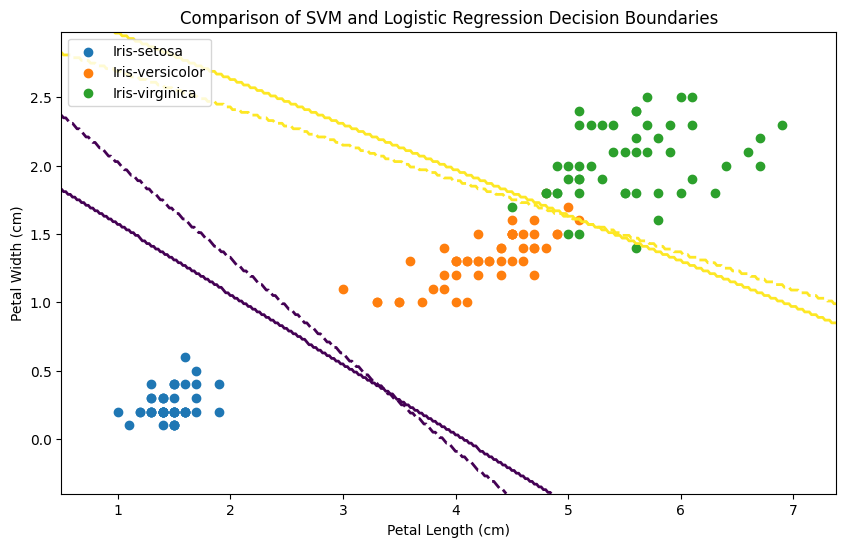

In [35]:
# Task 9 - Compare SVM and Logistic Regression

plt.figure(figsize=(10, 6))

# Plot SVM decision boundary
plt.contour(
    xx,
    yy,
    Z_numeric,
    levels=[0.5, 1.5],
    linewidths=2
)

# Plot Logistic Regression decision boundary
plt.contour(
    xx,
    yy,
    Z_logistic_numeric,
    levels=[0.5, 1.5],
    linestyles='--',
    linewidths=2
)

# Plot the data points
for class_name in [
    'Iris-setosa',
    'Iris-versicolor',
    'Iris-virginica'
]:
    mask = y_2d == class_name

    plt.scatter(
        X_2d.loc[mask, 'PetalLengthCm'],
        X_2d.loc[mask, 'PetalWidthCm'],
        label=class_name
    )

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Comparison of SVM and Logistic Regression Decision Boundaries')
plt.legend()
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [36]:
# Task 10 - Compare Performance of SVM and Logistic Regression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Calculate accuracy
svm_accuracy = accuracy_score(y2_test, svm_2d.predict(X2_test_scaled))
logistic_accuracy = accuracy_score(y2_test, y_pred_logistic)

# Display accuracy
print("SVM Accuracy:", svm_accuracy)
print("Logistic Regression Accuracy:", logistic_accuracy)

# SVM Confusion Matrix
print("\nSVM Confusion Matrix:")
print(confusion_matrix(y2_test, svm_2d.predict(X2_test_scaled)))

# Logistic Regression Confusion Matrix
print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y2_test, y_pred_logistic))

# SVM Classification Report
print("\nSVM Classification Report:")
print(classification_report(
    y2_test,
    svm_2d.predict(X2_test_scaled)
))

# Logistic Regression Classification Report
print("\nLogistic Regression Classification Report:")
print(classification_report(
    y2_test,
    y_pred_logistic
))

SVM Accuracy: 0.9333333333333333
Logistic Regression Accuracy: 0.9333333333333333

SVM Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Logistic Regression Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

SVM Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


Logistic Regression Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg      

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.